# Spotify Similarity Analysis
Multi-dimensional similarity measure between Sriharsha and Janya's listening profiles. First, import all necessary libraries

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from scipy.spatial.distance import jensenshannon

plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='darkgrid')

## 1. Load Data

In [2]:
import os
BASE = os.path.abspath('.')

def load_user(folder):
    records = []
    for i in range(5):
        try:
            records += json.load(open(f'{BASE}/public/{folder}/StreamingHistory_music_{i}.json', encoding='utf-8'))
        except FileNotFoundError:
            break
    df = pd.DataFrame(records)
    df = df[df['msPlayed'] >= 5000].copy()
    df['endTime'] = pd.to_datetime(df['endTime'], utc=True).dt.tz_convert('America/Chicago')
    df['minutes'] = df['msPlayed'] / 60000
    df['hour'] = df['endTime'].dt.hour
    df['dow'] = df['endTime'].dt.dayofweek
    df['month'] = df['endTime'].dt.month
    df['date'] = df['endTime'].dt.date
    df['track_key'] = df['trackName'] + ' | ' + df['artistName']
    return df

sri = load_user('s')
jan = load_user('j')

track_info = json.load(open(f'{BASE}/public/track_info.json', encoding='utf-8'))

print(f'Sriharsha: {len(sri):,} plays | Janya: {len(jan):,} plays')
print(f'Track info cache: {len(track_info):,} tracks')

Sriharsha: 10,422 plays | Janya: 14,153 plays
Track info cache: 6,591 tracks


Streaming data is loaded for both users. For the purpose of this analysis, we only consider plays that are 5 seconds or longer to avoid accidental skips that might skew the data. Time is converted to Central Time for later hourly analysis so that hours are easier to observe. 

## 2. Dimension 1 — Artist Overlap by weighted jaccard

Artists Sriharsha: 775
Artists Janya:     1,104
Shared artists:    20
Set Jaccard similarity:      0.0108
Weighted Jaccard similarity: 0.0011


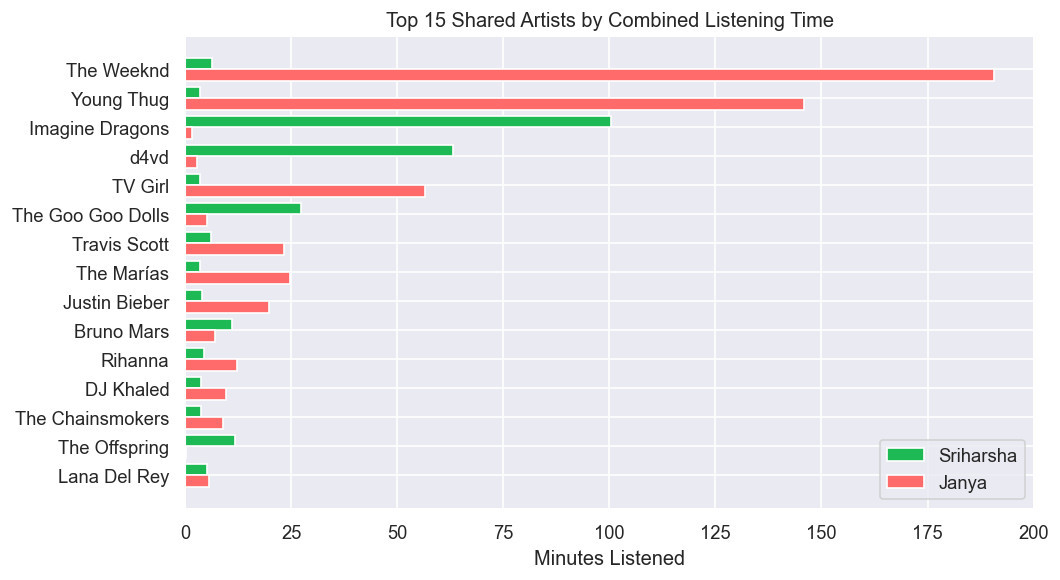

In [3]:
def artist_minutes(df):
    return df.groupby('artistName')['minutes'].sum()

sri_artists = artist_minutes(sri)
jan_artists = artist_minutes(jan)

all_artists = sri_artists.index.union(jan_artists.index)
s = sri_artists.reindex(all_artists, fill_value=0)
j = jan_artists.reindex(all_artists, fill_value=0)

# Weighted Jaccard: sum(min(s,j)) / sum(max(s,j))
weighted_jaccard = np.minimum(s, j).sum() / np.maximum(s, j).sum()

# Standard Jaccard on sets
sri_set = set(sri_artists.index)
jan_set = set(jan_artists.index)
shared = sri_set & jan_set
set_jaccard = len(shared) / len(sri_set | jan_set)

print(f'Artists Sriharsha: {len(sri_set):,}')
print(f'Artists Janya:     {len(jan_set):,}')
print(f'Shared artists:    {len(shared):,}')
print(f'Set Jaccard similarity:      {set_jaccard:.4f}')
print(f'Weighted Jaccard similarity: {weighted_jaccard:.4f}')

# Top shared artists by combined listening time
shared_df = pd.DataFrame({'sri_min': s, 'jan_min': j}).loc[list(shared)]
shared_df['combined'] = shared_df['sri_min'] + shared_df['jan_min']
top_shared = shared_df.sort_values('combined', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(top_shared))
w = 0.4
ax.barh(x - w/2, top_shared['sri_min'], w, label='Sriharsha', color='#1DB954')
ax.barh(x + w/2, top_shared['jan_min'], w, label='Janya', color='#FF6B6B')
ax.set_yticks(x)
ax.set_yticklabels(top_shared.index)
ax.invert_yaxis()
ax.set_xlabel('Minutes Listened')
ax.set_title('Top 15 Shared Artists by Combined Listening Time')
ax.legend()
plt.tight_layout()
plt.show()

The similarity measurement we decieded to use for artist comparison is weighted Jaccard. We decided to use weighted Jaccard over standard Jaccard Because the standard procedure only takes into account the fact that two users have listened to the same artist. So essentially it would take all intersecting elements between both sets, And divide it by the total amount of elements in both sets. This is inaccurate because, as seen in the chart above, two users could listen to the same artist but have drastically different listening times. This measure should thus be weighted. The calculated score of 0.0011 shows that there is almost no overlap in artists between the two users.  

The above graph displays the artists with the highest total listening time between both users. It is apparent after observation that despite artists like the weekend having the highest amount of total listening time, there is a clear disrepancy between both both users, with listening being heavily skewed by Janya. This is observation is objectively measured by jaccards metric. 

## Cosine Similarity
No, you can't. No, not yet. You just lead. 
For all temporal and audio feature dimensions, we will use cosine similarity as our similarity function. Unlike a Euclidean distance function where The distance between two vectors Is calculated, The cosine similarity function measures the angle between two vectors to signify whether they point in the same direction. If the two vectors point in the same direction identically, then they are awarded the maximal score, which is 1.0. If the two vectors are orthogonal, then they get a score of 0.0. 

We are using the cosine similarity function for temporal data because There is a distinct difference in total volume of listening time and total plays between both users with Sriharsha Having 10,422 plays, While Jania has 14,153 plates. This is a 36% difference in total volume. Euclidean distance without normalization would heavily penalize this difference. Cosine ignores this magnitude entirely and only compares whether the two vectors point in the same direction. 

We use the cosine similarity function for audio data Because features like energy, sensibility or happiness describe the type of music someone prefers. For us this means that it doesn't matter much whether the Feature values have exactly the same value, but more so the fact that they gravitate generally to the same type of music. 

![cosine similarity function](cosinesimilarity.png)

## 3. Listening Pattern (Cosine Similarity)

Hourly pattern cosine similarity: 0.5751  (JSD: 0.3758)
Day-of-week cosine similarity:    0.9692  (JSD: 0.0903)


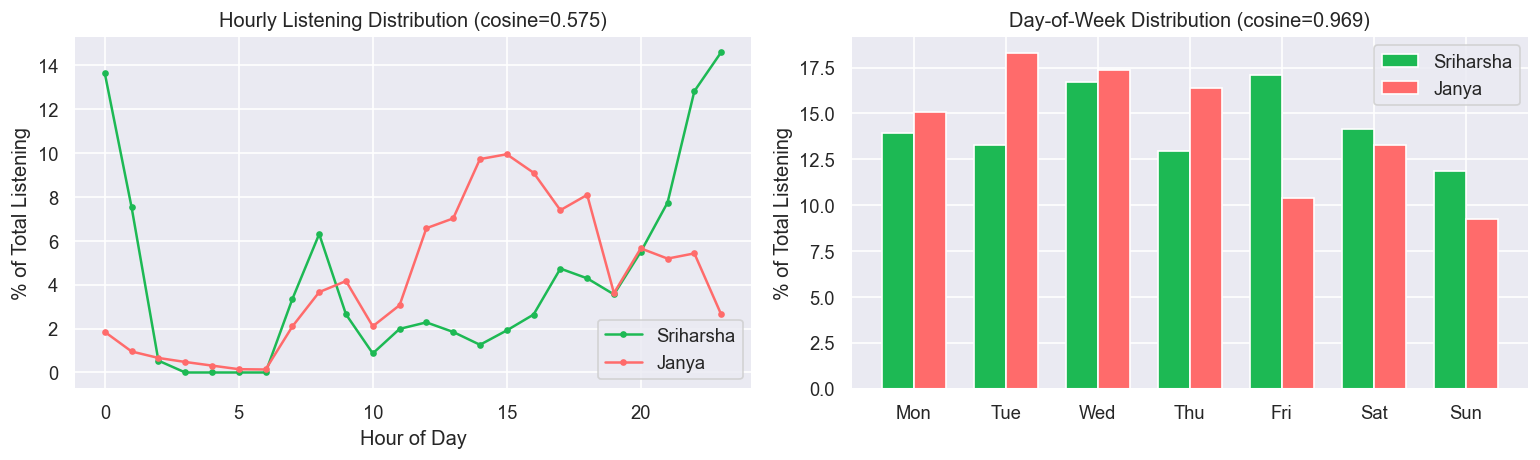

In [4]:
def norm_dist(series, n):
    v = series.reindex(range(n), fill_value=0).values.astype(float)
    return v / v.sum() if v.sum() > 0 else v

# Hourly distribution
sri_hour = norm_dist(sri.groupby('hour')['minutes'].sum(), 24)
jan_hour = norm_dist(jan.groupby('hour')['minutes'].sum(), 24)
hour_sim = cosine_similarity([sri_hour], [jan_hour])[0, 0]

# Day-of-week distribution
sri_dow = norm_dist(sri.groupby('dow')['minutes'].sum(), 7)
jan_dow = norm_dist(jan.groupby('dow')['minutes'].sum(), 7)
dow_sim = cosine_similarity([sri_dow], [jan_dow])[0, 0]

# Jensen-Shannon divergence (lower = more similar) as an alternative
hour_jsd = jensenshannon(sri_hour, jan_hour)
dow_jsd  = jensenshannon(sri_dow, jan_dow)

print(f'Hourly pattern cosine similarity: {hour_sim:.4f}  (JSD: {hour_jsd:.4f})')
print(f'Day-of-week cosine similarity:    {dow_sim:.4f}  (JSD: {dow_jsd:.4f})')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
hours = range(24)
axes[0].plot(hours, sri_hour * 100, label='Sriharsha', color='#1DB954', marker='o', ms=3)
axes[0].plot(hours, jan_hour * 100, label='Janya', color='#FF6B6B', marker='o', ms=3)
axes[0].set_title(f'Hourly Listening Distribution (cosine={hour_sim:.3f})')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('% of Total Listening')
axes[0].legend()

days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
x = np.arange(7)
w = 0.35
axes[1].bar(x - w/2, sri_dow * 100, w, label='Sriharsha', color='#1DB954')
axes[1].bar(x + w/2, jan_dow * 100, w, label='Janya', color='#FF6B6B')
axes[1].set_xticks(x)
axes[1].set_xticklabels(days)
axes[1].set_title(f'Day-of-Week Distribution (cosine={dow_sim:.3f})')
axes[1].set_ylabel('% of Total Listening')
axes[1].legend()

plt.tight_layout()
plt.show()

### Temporal Listening Pattern — Cosine Similarity


Seen above is the hourly listening distribution between both users. We can observe that the hourly listening distribution for Sri peaks at around 11:00 PM Central Time, Indicating that this person is likely a nightly listener. There is another peak for Sri Earlier in the day at around 6:00 AM. This could indicate a listening period during his morning commute. 

For Janya, Listening time peaks at around midday during 3:00 PM. This supports our hypothesis that the user likely listens to music to focus during study sessions, Or other high focus activities. The cosine similarity metric for hourly Listening distributions Is 0.5751, Which indicates that the hourly listening distributions between both listeners are significantly different. The day of the week cosine similarity metric, however, tells a different story, with an output of 0.9692. The drop in user listening frequency as the week approaches the weekend is shared for both users and is irrespective of their hourly listening periods. This likely reflects a shared academic schedule where workload of students decreases as the weekend approaches. 

## 4. Dimension 3 — Seasonality (Monthly Distribution)

Monthly seasonality cosine similarity: 0.8758  (JSD: 0.1911)


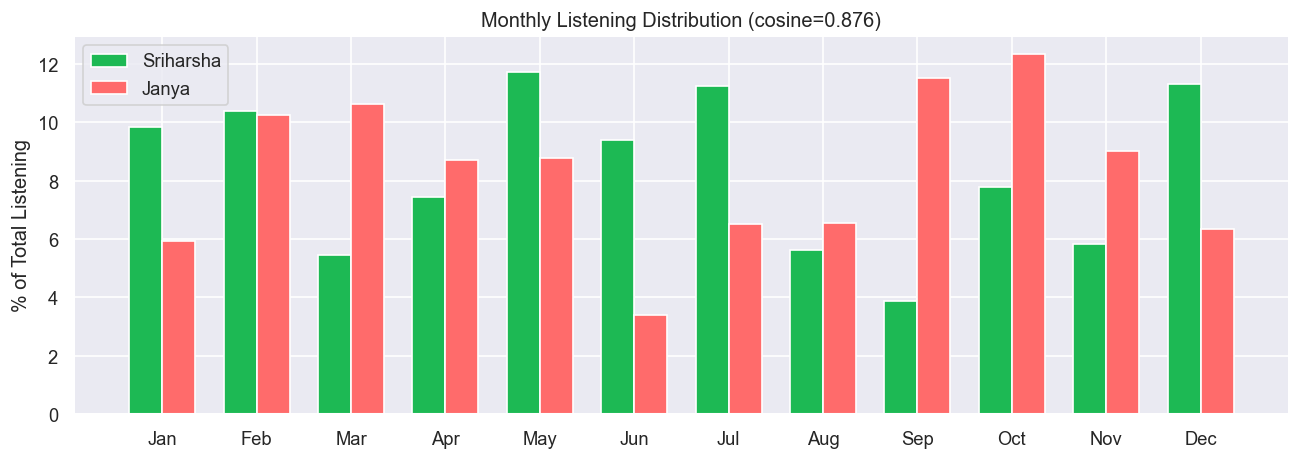

In [5]:
sri_month = norm_dist(sri.groupby('month')['minutes'].sum(), 13)[1:]  # months 1–12
jan_month = norm_dist(jan.groupby('month')['minutes'].sum(), 13)[1:]
month_sim = cosine_similarity([sri_month], [jan_month])[0, 0]
month_jsd = jensenshannon(sri_month, jan_month)

print(f'Monthly seasonality cosine similarity: {month_sim:.4f}  (JSD: {month_jsd:.4f})')

month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
x = np.arange(12)
w = 0.35
fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(x - w/2, sri_month * 100, w, label='Sriharsha', color='#1DB954')
ax.bar(x + w/2, jan_month * 100, w, label='Janya', color='#FF6B6B')
ax.set_xticks(x)
ax.set_xticklabels(month_labels)
ax.set_title(f'Monthly Listening Distribution (cosine={month_sim:.3f})')
ax.set_ylabel('% of Total Listening')
ax.legend()
plt.tight_layout()
plt.show()

### Monthly Seasonality — Cosine Similarity

We are again using cosine similarity here for the same reason that we used it in the temporal Data above, Which is the monthly distributions are usually normalized continuous vectors. A good rule of thumb is that any time you are dealing with data over a period of time, that data would be considered continuous and it would be more appropriate to apply cosine similarity as opposed to a discrete similarity metric. We can observe here that Janya has Her listening time peaked during the months of October and September, as well as February and March. We can draw two viable conclusions from this, which is that she might be traveling extensively over the course of the off semesters where she doesn't have school, or she uses music as a form and tool for focus(or both). In contrast, Sriharsha Seems to listen to music during the off seasons most. Like for example December, January and May through July. One could conclude that Sriharsha may use music as a form of relaxation as opposed to focus. Despite the listing peaks differing significantly between both users. We still get a score of 0.876. We could attribute this to the fact that Both distributions have overall similar shapes, but one distribution is shifted slightly. 

## 5. Dimension 4 — Audio Feature Profile

Audio feature profile cosine similarity (normalized): 0.9783
Sriharsha coverage: 10,407 / 10,422 plays (99.9%)
Janya coverage:     13,931 / 14,153 plays (98.4%)


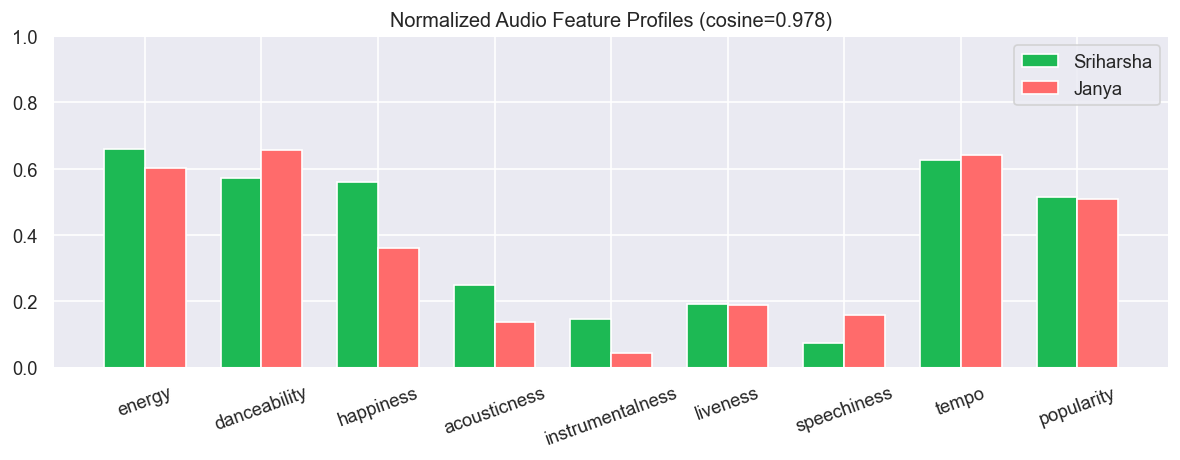

Feature-by-feature comparison (normalized 0-1):
                  Sriharsha  Janya
energy                0.660  0.602
danceability          0.571  0.656
happiness             0.560  0.362
acousticness          0.249  0.137
instrumentalness      0.147  0.043
liveness              0.192  0.188
speechiness           0.073  0.159
tempo                 0.625  0.642
popularity            0.515  0.510


In [6]:
AUDIO_FEATURES = ['energy', 'danceability', 'happiness', 'acousticness',
                  'instrumentalness', 'liveness', 'speechiness', 'tempo', 'popularity']

# Min/max ranges for normalization (tempo is 0-200, all others 0-100)
FEATURE_RANGES = {
    'energy': (0, 100), 'danceability': (0, 100), 'happiness': (0, 100),
    'acousticness': (0, 100), 'instrumentalness': (0, 100), 'liveness': (0, 100),
    'speechiness': (0, 100), 'tempo': (0, 200), 'popularity': (0, 100)
}

def audio_profile(df):
    rows = []
    for _, row in df.iterrows():
        info = track_info.get(row["track_key"])
        if info:
            feat = {f: info.get(f) for f in AUDIO_FEATURES}
            if all(v is not None for v in feat.values()):
                feat["minutes"] = row["minutes"]
                rows.append(feat)
    fdf = pd.DataFrame(rows)
    weights = fdf["minutes"]
    return (fdf[AUDIO_FEATURES].multiply(weights, axis=0).sum() / weights.sum()), fdf

sri_profile, sri_feat_df = audio_profile(sri)
jan_profile, jan_feat_df = audio_profile(jan)

# Normalize each feature to 0-1 scale
def normalize_profile(profile):
    normed = profile.copy()
    for f, (lo, hi) in FEATURE_RANGES.items():
        normed[f] = (profile[f] - lo) / (hi - lo)
    return normed

sri_norm = normalize_profile(sri_profile)
jan_norm = normalize_profile(jan_profile)

audio_sim = cosine_similarity([sri_norm.values], [jan_norm.values])[0, 0]
print(f"Audio feature profile cosine similarity (normalized): {audio_sim:.4f}")
print(f"Sriharsha coverage: {len(sri_feat_df):,} / {len(sri):,} plays ({100*len(sri_feat_df)/len(sri):.1f}%)")
print(f"Janya coverage:     {len(jan_feat_df):,} / {len(jan):,} plays ({100*len(jan_feat_df)/len(jan):.1f}%)")

compare = pd.DataFrame({"Sriharsha": sri_norm, "Janya": jan_norm})
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(AUDIO_FEATURES))
w = 0.35
ax.bar(x - w/2, compare["Sriharsha"], w, label="Sriharsha", color="#1DB954")
ax.bar(x + w/2, compare["Janya"], w, label="Janya", color="#FF6B6B")
ax.set_xticks(x)
ax.set_xticklabels(AUDIO_FEATURES, rotation=20)
ax.set_ylim(0, 1)
ax.set_title(f"Normalized Audio Feature Profiles (cosine={audio_sim:.3f})")
ax.legend()
plt.tight_layout()
plt.show()

print("Feature-by-feature comparison (normalized 0-1):")
print(compare.round(3))

### Audio Feature Profile — Cosine Similarity

Before analysis it is important to note that we normalize the features on a zero to one scale before computing similarity. Without normalization. Tempo, which is on a scale of zero to 200 as opposed to the other features, would skew the dot product and inflate the similarity score. We again used cosine similarity here because audio features are continuous variables and not probability distributions.

The computed score for the cosine similarity metric for this comparison was 0.978, which indicates a nearly identical audio taste. We can observe from the graphs that both tend towards high energy, danceable music at around 125 BPM. Some differences include that on average, Sri Harsha listens to slightly happier music and more instrumental tracks, while Jania leads towards More vocal tracks. 

## 6. Composite Similarity Score

=== Similarity Dimensions ===
  Artist Overlap (Weighted Jaccard)          0.0011  (weight=20%)
  Hourly Pattern (Cosine)                    0.5751  (weight=20%)
  Day-of-Week Pattern (Cosine)               0.9692  (weight=20%)
  Monthly Seasonality (Cosine)               0.8758  (weight=20%)
  Audio Feature Profile (Cosine)             0.9783  (weight=20%)
COMPOSITE SIMILARITY SCORE: 0.6799


/var/folders/4c/tjx2vrgn6_1_l2j37xlgf3nm0000gn/T/ipykernel_2597/2918384840.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(labels, rotation=20, ha="right")


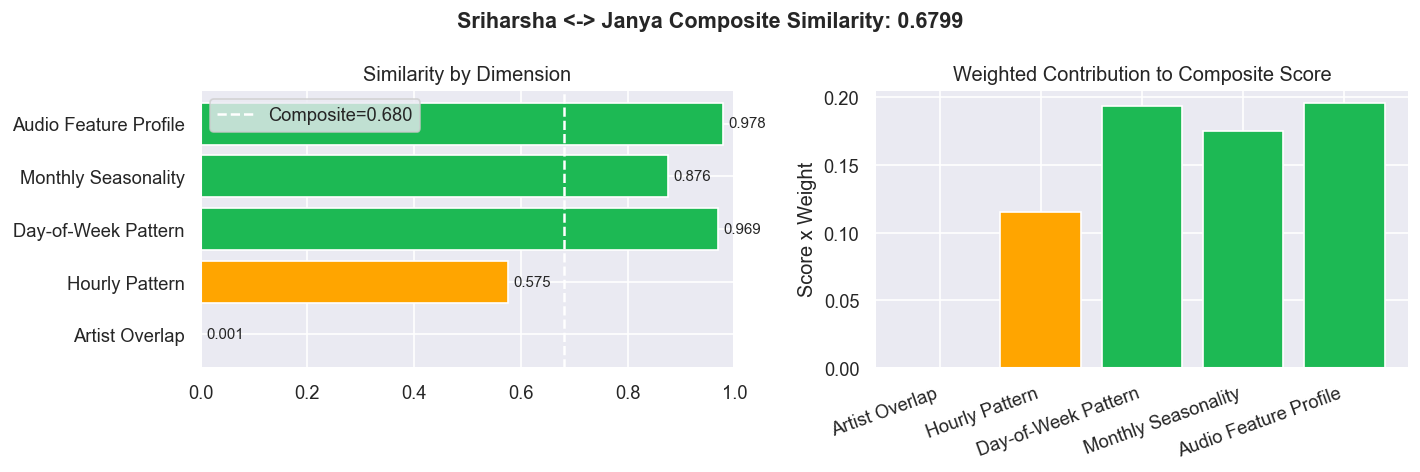

In [7]:
# Equal weights across all 5 dimensions
WEIGHTS = {
    'Artist Overlap (Weighted Jaccard)': (weighted_jaccard, 0.20),
    'Hourly Pattern (Cosine)':           (hour_sim,         0.20),
    'Day-of-Week Pattern (Cosine)':      (dow_sim,          0.20),
    'Monthly Seasonality (Cosine)':      (month_sim,        0.20),
    'Audio Feature Profile (Cosine)':    (audio_sim,        0.20),
}

composite = sum(score * w for score, w in WEIGHTS.values())

print("=== Similarity Dimensions ===")
for name, (score, w) in WEIGHTS.items():
    print(f"  {name:<42} {score:.4f}  (weight={w:.0%})")
print(f"COMPOSITE SIMILARITY SCORE: {composite:.4f}")

# Visualise
labels = [n.split(" (")[0] for n in WEIGHTS]
scores = [v[0] for v in WEIGHTS.values()]
weights = [v[1] for v in WEIGHTS.values()]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = ["#1DB954" if s >= 0.7 else "#FFA500" if s >= 0.4 else "#FF6B6B" for s in scores]
bars = axes[0].barh(labels, scores, color=colors)
axes[0].set_xlim(0, 1)
axes[0].axvline(composite, color="white", linestyle="--", linewidth=1.5, label=f"Composite={composite:.3f}")
axes[0].set_title("Similarity by Dimension")
axes[0].legend()
for bar, s in zip(bars, scores):
    axes[0].text(s + 0.01, bar.get_y() + bar.get_height()/2, f"{s:.3f}", va="center", fontsize=9)

contributions = [s * w for s, w in zip(scores, weights)]
axes[1].bar(labels, contributions, color=colors)
axes[1].set_title("Weighted Contribution to Composite Score")
axes[1].set_xticklabels(labels, rotation=20, ha="right")
axes[1].set_ylabel("Score x Weight")

plt.suptitle(f"Sriharsha <-> Janya Composite Similarity: {composite:.4f}", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### Composite Score

Before calculating the composite score, each of the features were given equal weight(20%) for the purposes of avoiding arbitrary assumptions about whether dimension A matters more than dimension B for music taste. In this comparison alone, one could make the argument that artists overlap is what determines the Similarity of two users. However, it is very apparent that they have little to no artists overlap while also having Very similar audio feature profiles. 

Calculation of the composite score gave us 0.68, which reflects very high similarity. In four out of the five dimensions, but, As observed in the left graph, It was heavily skewed By the little to no artist overlap. If artists overlap was not a feature, the composite score calculated would be 0.85. 

A limitation of this composite measure is that Not only are all the features given equal weight, but The features are treated as independent dimensions. Means that two users who score highly on. 4 dimensions but. Score zero on one dimension. Are penalized equally, regardless of how many dimensions actually align. 

## 7. Evaluating the Similarity Measure

To assess whether the measure is meaningful, we generate a synthetic, disimilar user who has no relationship with Sriharsha or Janya.  


In [8]:
def compute_composite(df_a, df_b):
    """Compute the 5-dimension composite similarity score between two user DataFrames."""
    # 1. Weighted Jaccard on artist minutes
    a_art = df_a.groupby('artistName')['minutes'].sum()
    b_art = df_b.groupby('artistName')['minutes'].sum()
    all_art = a_art.index.union(b_art.index)
    av = a_art.reindex(all_art, fill_value=0)
    bv = b_art.reindex(all_art, fill_value=0)
    wj = float(np.minimum(av, bv).sum() / np.maximum(av, bv).sum()) if np.maximum(av, bv).sum() > 0 else 0.0

    # 2. Hourly cosine similarity
    a_hour = norm_dist(df_a.groupby('hour')['minutes'].sum(), 24)
    b_hour = norm_dist(df_b.groupby('hour')['minutes'].sum(), 24)
    h_sim = float(cosine_similarity([a_hour], [b_hour])[0, 0])

    # 3. Day-of-week cosine similarity
    a_dow = norm_dist(df_a.groupby('dow')['minutes'].sum(), 7)
    b_dow = norm_dist(df_b.groupby('dow')['minutes'].sum(), 7)
    d_sim = float(cosine_similarity([a_dow], [b_dow])[0, 0])

    # 4. Monthly seasonality cosine similarity
    a_mon = norm_dist(df_a.groupby('month')['minutes'].sum(), 13)[1:]
    b_mon = norm_dist(df_b.groupby('month')['minutes'].sum(), 13)[1:]
    m_sim = float(cosine_similarity([a_mon], [b_mon])[0, 0])

    # 5. Audio feature cosine similarity
    def get_audio_profile(df):
        rows = []
        for _, row in df.iterrows():
            info = track_info.get(row['track_key'])
            if info:
                feat = {f: info.get(f) for f in AUDIO_FEATURES}
                if all(v is not None for v in feat.values()):
                    feat['minutes'] = row['minutes']
                    rows.append(feat)
        if not rows:
            return None
        fdf = pd.DataFrame(rows)
        weights = fdf['minutes']
        profile = fdf[AUDIO_FEATURES].multiply(weights, axis=0).sum() / weights.sum()
        normed = profile.copy()
        for f, (lo, hi) in FEATURE_RANGES.items():
            normed[f] = (profile[f] - lo) / (hi - lo)
        return normed.values

    pa = get_audio_profile(df_a)
    pb = get_audio_profile(df_b)
    a_sim = float(cosine_similarity([pa], [pb])[0, 0]) if pa is not None and pb is not None else 0.0

    return (wj + h_sim + d_sim + m_sim + a_sim) / 5.0

Sri  vs Janya:     0.6799  (observed)
Sri  vs Synthetic: 0.5310  (baseline)
Janya vs Synthetic:0.5464  (baseline)


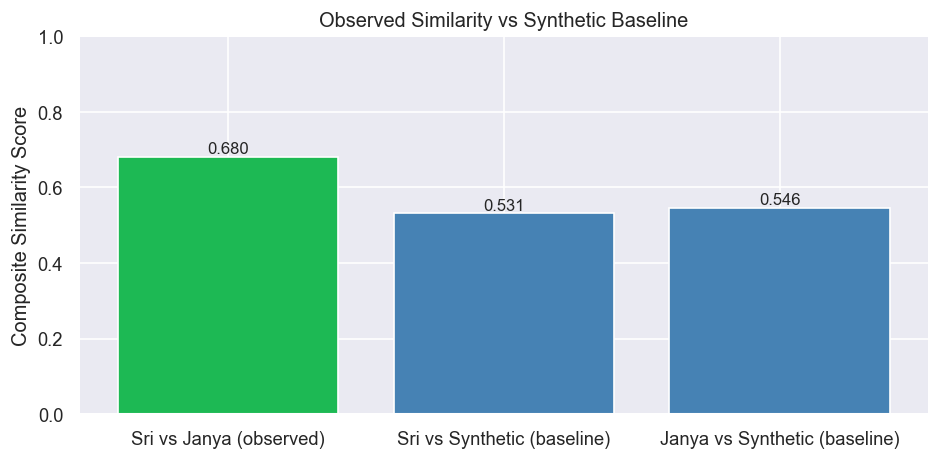

In [9]:
import random

def generate_synthetic_user(n_plays=12000, seed=42):
    rng = np.random.default_rng(seed)
    # Sample random artists from a large pool unrelated to sri/jan
    fake_artists = [f'Synthetic Artist {i}' for i in range(500)]
    fake_tracks  = [f'Synthetic Track {i}'  for i in range(2000)]
    rows = []
    for _ in range(n_plays):
        rows.append({
            'artistName': rng.choice(fake_artists),
            'trackName':  rng.choice(fake_tracks),
            'msPlayed':   int(rng.uniform(5000, 300000)),
            'endTime':    pd.Timestamp('2024-01-01', tz='America/Chicago') + pd.Timedelta(seconds=int(rng.uniform(0, 365*24*3600)))
        })
    df = pd.DataFrame(rows)
    df['minutes'] = df['msPlayed'] / 60000
    df['hour']  = df['endTime'].dt.hour
    df['dow']   = df['endTime'].dt.dayofweek
    df['month'] = df['endTime'].dt.month
    df['date']  = df['endTime'].dt.date
    df['track_key'] = df['trackName'] + ' | ' + df['artistName']
    return df

synthetic = generate_synthetic_user()

sri_vs_syn = compute_composite(sri, synthetic)
jan_vs_syn = compute_composite(jan, synthetic)

print(f'Sri  vs Janya:     {composite:.4f}  (observed)')
print(f'Sri  vs Synthetic: {sri_vs_syn:.4f}  (baseline)')
print(f'Janya vs Synthetic:{jan_vs_syn:.4f}  (baseline)')

labels  = ['Sri vs Janya (observed)', 'Sri vs Synthetic (baseline)', 'Janya vs Synthetic (baseline)']
scores  = [composite, sri_vs_syn, jan_vs_syn]
colors  = ['#1DB954', 'steelblue', 'steelblue']

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(labels, scores, color=colors)
ax.set_ylim(0, 1)
ax.set_ylabel('Composite Similarity Score')
ax.set_title('Observed Similarity vs Synthetic Baseline')
for bar, s in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width()/2, s + 0.01, f"{s:.3f}", ha="center", fontsize=10)
plt.tight_layout()
plt.show()

### Synthetic Baseline Test Analysis
To assess whether our composite score was meaningful from the previous section, we generated a synthetic baseline user That was purposely dissimilar to both Sri and Janya. Our hypothesis Is that if our composite score is statistically significant, Then Sri vs Janya should score higher than either user vs a random listener. 

The synthetic user was generated by seating uniformly random timestamp data. Across the year. And also seeding completely fake artists that have no overlap with either real user. This means that discrete variables like artist overlap and audio feature scores are essentially forced to zero while temporal dimension scores That measure a variable overtime Are computed By comparing alignment with a flat distribution.

Our results show that Tree versus Jania score 0.680 composite score, Compared to 0.531 and 0.546. For Sri versus synthetic and Janya versus Synthetic respectively. We can observe here that there is a significant gap of around 0.15. 

This evaluation, of course, has a key limitation that we must discuss. The synthetic baseline is not truly random. And does not actually represent a completely unrelated real listener. A real person would have at least a few popular artists and would also share sleep based time patterns. This means that the synthetic baseline Likely both underestimates a truly dissimilar baseline. While also overestimating the gap. 

A better Test for evaluating whether our composite measure is actually significant would be to obtain a 3rd person Spotify data and use that as an actual baseline. Thus we cannot Assert that our Composite score is indicative of True similarity between the two users. We should also, however, mention that An argument could be made that although there is an evident lack in overlap In shared artist's between the two users, it could be dropped as an outlier.

## 8. Per-Dimension Summary Table

In [10]:
summary = pd.DataFrame([
    {"Dimension": "Artist Overlap",       "Metric": "Weighted Jaccard", "Score": weighted_jaccard, "Weight": 0.20},
    {"Dimension": "Hourly Pattern",       "Metric": "Cosine Similarity","Score": hour_sim,          "Weight": 0.20},
    {"Dimension": "Day-of-Week Pattern",  "Metric": "Cosine Similarity","Score": dow_sim,           "Weight": 0.20},
    {"Dimension": "Monthly Seasonality",  "Metric": "Cosine Similarity","Score": month_sim,         "Weight": 0.20},
    {"Dimension": "Audio Feature Profile","Metric": "Cosine Similarity","Score": audio_sim,         "Weight": 0.20},
    {"Dimension": "COMPOSITE",            "Metric": "Equal Weighted Avg","Score": composite,         "Weight": 1.00},
])
summary["Weighted Score"] = (summary["Score"] * summary["Weight"]).round(4)
summary["Score"] = summary["Score"].round(4)
print(summary.to_string(index=False))

            Dimension             Metric  Score  Weight  Weighted Score
       Artist Overlap   Weighted Jaccard 0.0011     0.2          0.0002
       Hourly Pattern  Cosine Similarity 0.5751     0.2          0.1150
  Day-of-Week Pattern  Cosine Similarity 0.9692     0.2          0.1938
  Monthly Seasonality  Cosine Similarity 0.8758     0.2          0.1752
Audio Feature Profile  Cosine Similarity 0.9783     0.2          0.1957
            COMPOSITE Equal Weighted Avg 0.6799     1.0          0.6799


### Summary and Discussion of AI Use
AI was used for code and graphical generation. Any conceptual decision(for example, choosing equal weights for composite scoring, using a synthetic user for measurement assesment, etc) Did not warrant the use of AI. All interpretations of graphs and following analysis Did not warrant the use of AI. 